# **Data Preprocessing**

Student Dropout Prediction

Fall 2024 Data Science Project

Riya Thapar, Nikhil Raja, Samhitha Gandla, Ananya Srinivasan, Naveena Pillai

Riya Thapar:
*   A: We collaborated on the project idea
*   F: Riya coded the outlier analysis and wrote the explanations for all of the visualizations
*   G: Riya did the report formatting for the header, introduction, and data curation sections.


Nikhil Raja:
*   A: We collaborated on the project idea
*   C: Nikhil coded the correlation test and did so by defining the hypothesis and implementing a chi square test of independence. He also created the visualizations.
*   D: Nikhil did all of the ML Algo Design/Development
*   E: Nikhil did all of the ML Algorithm Training and Test Data Analysis
*   F: Nikhil did parts of the results analysis.


Samhitha Gandla:
*   A: We collaborated on the project idea
*   F: Samhitha coded hypothesis testing on GPA and student dropout using a t-test, including data grouping and statistical analysis.
*   G: Samhitha contributed to the Insights and Conclusions section, summarizing key findings of the project.

Ananya Srinivasan:
*   A: We collaborated on the project idea
*   B: Ananya contributed to the data curation and preprocessing by cleaning the dataset, handling missing values, and preparing the data for exploratory analysis and machine learning.
*   G: Ananya did the report formatting for the data preprocessing and basic data curation sections. Ananya published the project on Github Pages.


Naveena Pillai:
*   A: We collaborated on the project idea
*   B: Naveena contributed to the data curation and preprocessing by cleaning the dataset, handling missing values, and preparing the data for exploratory analysis and machine learning.
*   F: Naveena created visualizations to compare the performance of the machine learning models and organized the model results into clear tables and plots to support result analysis.

# **Introduction:**

Our data is about student dropout rates, which we are trying to predict. As college students, this is a topic that impacts all of us and we look to analyze what might be the underlying cause of student success / student drop out rates via the dataset. By identifying insights from the data, college institutions would be able to leverage those results into actionable methods to further improve the student academic experience.

# **Data Curation**

We are using the Student Dropout Prediction Dataset from Kaggle. The dataset contains approximately 10,000 student records with 19 features capturing demographic, academic, and behavioral factors such as study hours, family income, stress levels, and scholarship status. These features are relevant because they may influence whether a student drops out.

During preprocessing, missing values were handled to ensure consistency in the dataset. For example, missing values in features like Family_Income and Study_Hours_per_Day were filled using median values to reduce the impact of outliers. Other missing categorical values were either imputed or removed depending on their significance. These steps ensure the dataset is clean and suitable for analysis and machine learning.

https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset


In [1]:
import kagglehub
import pandas as pd
import os
from scipy.stats import zscore
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("meharshanali/student-dropout-prediction-dataset")
file_path = os.path.join(path, "student_dropout_dataset_v3.csv")
df = pd.read_csv(file_path)
df.head()


Using Colab cache for faster access to the 'student-dropout-prediction-dataset' dataset.


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [2]:
# Replace missing values with median
df['Parental_Education'] = df['Parental_Education'].fillna('None')

df['Family_Income'] = df['Family_Income'].fillna(
    df.groupby('Parental_Education')['Family_Income'].transform('median')
)
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(
    df.groupby(['Semester', 'Department', 'Part_Time_Job'])
    ['Study_Hours_per_Day'].transform('median')
)
df['Stress_Index'] = df['Stress_Index'].fillna(
    df.groupby(['Semester', 'Department', 'Part_Time_Job'])
    ['Stress_Index'].transform('median')
)

df.isna().sum()

,0
Student_ID,0
Age,0
Gender,0
Family_Income,0
Internet_Access,0
Study_Hours_per_Day,0
Attendance_Rate,0
Assignment_Delay_Days,0
Travel_Time_Minutes,0
Part_Time_Job,0


# **Basic Data Exploration**
Our dataset contains data that represents an academic environment. There are 19 features, including student age, gender, family income, access to internet, average study hours per day, attendance rate, assignment delay, commute time, part time job, scholarship, stress index, gpa, current year, department, and highest level of parental education. These features can be analyzed to predict and determine student academic performance and dropout. There are 10,000 entries in the dataset, representing 10,000 different students in an academic setting.

**Hypothesis Testing: Effect of GPA on Student Dropout**

To determine whether academic performance impacts student dropout, we compare GPA between students who dropped out and those who did not.

Null Hypothesis (H₀): There is no significant difference in GPA between students who drop out and those who do not.

Alternative Hypothesis (H₁): There is a significant difference in GPA between students who drop out and those who do not.

We can use an independent two-sample t-test.


In [3]:
from scipy.stats import ttest_ind

dropout_group = df[df['Dropout'] == 1]['GPA'].dropna()
non_dropout_group = df[df['Dropout'] == 0]['GPA'].dropna()

t_stat, p_value = ttest_ind(dropout_group, non_dropout_group, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)
print("Mean GPA (Dropout):", dropout_group.mean())
print("Mean GPA (Non-Dropout):", non_dropout_group.mean())

# interpretation (IMPORTANT — matches your partner style)
if p_value < 0.05:
    print("Reject H0: GPA and dropout are significantly different")
else:
    print("Fail to reject H0: No significant difference in GPA between groups")



T-statistic: -52.998304100953824
P-value: 0.0
Mean GPA (Dropout): 1.4276125743415464
Mean GPA (Non-Dropout): 2.5796233324614177
Reject H0: GPA and dropout are significantly different


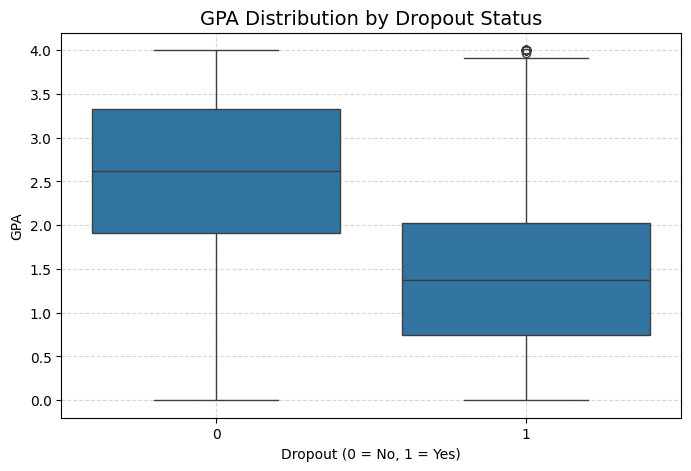

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x='Dropout', y='GPA', data=df)

plt.title("GPA Distribution by Dropout Status", fontsize=14)
plt.xlabel("Dropout (0 = No, 1 = Yes)")
plt.ylabel("GPA")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Explanation**

This is a box-and-whisker plot that shows the GPA distribution of students who dropped out and students who didn't. The box on the left is for students who did not drop out, and the box on the right is for students who did. While both groups had a wide ranges of GPA, students who did not drop out had a higher average GPA than students who did. This indicates that lower GPAs are correlated with students being more likely to drop-out, but the existence of students who dropped out with very high GPAs suggests that this is not the only factor.

There are 20 outliers total


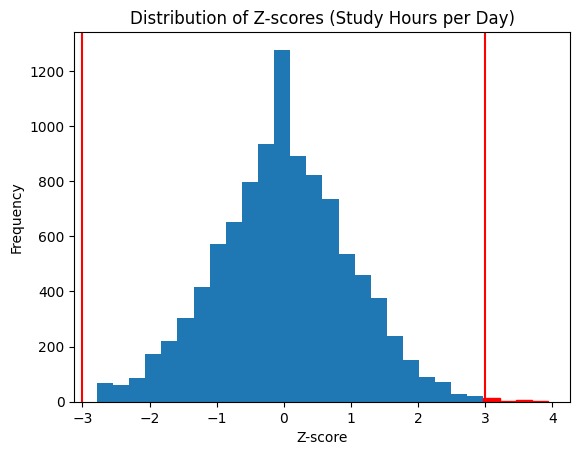

In [5]:
#Find outliers in Study_Hours_per_Day using z-score analysis
z_scores = zscore(df['Study_Hours_per_Day'])
outliers = df[abs(z_scores) > 3]
print("There are " + str(len(outliers)) + " outliers total")

plt.figure()

counts, bins, patches = plt.hist(z_scores, bins=28)

for i in range(len(patches)):
    if bins[i] < -3 or bins[i+1] > 3:
        patches[i].set_color('red')

plt.axvline(3, color='red')
plt.axvline(-3, color='red')

plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.title("Distribution of Z-scores (Study Hours per Day)")

plt.show()

**Explanation**

This is a bar chart intended to find any outliers in hours studied. It was determined that there were 20 outliers total, all of which were for students who studied significantly more than expected per day.

**Correlation Test**

We are looking to explore whether the a students scholarship status affects their droupout rate. We will use a chi sqaure test for this.

H0: Having a scholarship does not affect whether a student drops out.


Ha: Having a scholarship does affect whether a student drops out.

In [6]:
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt


table  = pd.crosstab(df["Scholarship"], df["Dropout"])


ch12, p, dof, exp = chi2_contingency(table)


print("Chi-square stat:", ch12)


print("P-Value:" , p)


if p<0.05:
 print("Reject H0 which is scholarship and droupout are associated")
else:
 print("Fail to reject H0 which is there is no statistically significant assocation between scholarship and droupout.")






Chi-square stat: 0.41146114076497986
P-Value: 0.5212288181760807
Fail to reject H0 which is there is no statistically significant assocation between scholarship and droupout.


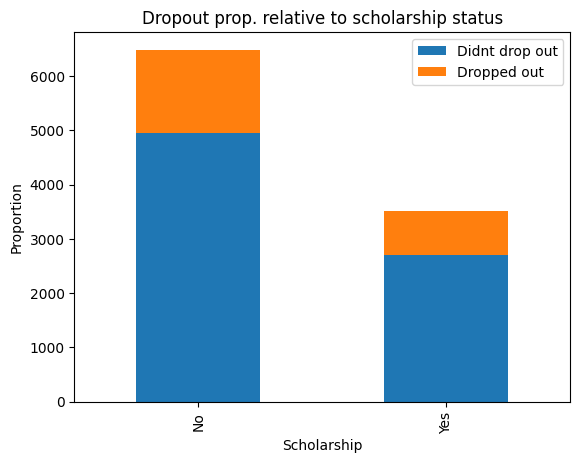

In [7]:
new_table  = pd.crosstab(df["Scholarship"], df["Dropout"])
new_table.columns = ["Didnt drop out", "Dropped out"]
new_table.plot(kind ="bar", stacked = "True")
plt.title("Dropout prop. relative to scholarship status")
plt.ylabel("Proportion")
plt.xlabel("Scholarship")
plt.show()


**Explanation**

This chart shows the number of students who dropped out based on whether or not they got a scholarship. Roughly the same proportion of students (around 23%) dropped out regardless of if they got a scholarship or not, so this mostly likely isn't a major factor in predicting dropout rates.

# **Primary Analysis**

### **Model Selection & Preprocessing**
After doing our intial exploratory analysis in stage 2 of this project, we chose to do a classification machine learning technique for our primary analysis. Since the result we are trying to predict (whether a person drops out or not) is a binary thing (0 or 1), we felt that classification would be a bit more appropriate then regression.

Before we began training the model, we split the data into two parts. The features like family income and scholarship status were stored insdie the new_table, while sol held the column we were targeting which was Dropout. We also used one hot encoding that we learned about in class to convert the categorical variables that were in new_table into numerical values so that the models could process them. After that, we split the data into training and testing through a 80-20 split (same as we have done for previous projects). Since Logistic Regression and KNN work best when numbers are all on a similar scale, we had to use a scaled version of the data when training/testing on them.

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns



In [9]:
new_table = df.drop(columns=["Dropout"])
sol = df["Dropout"]


#https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/
new_table = pd.get_dummies(new_table, drop_first = True)

#random state and test size taken from project 4
X_train, X_test, y_train, y_test = train_test_split(new_table, sol, test_size = 0.2, random_state=42, stratify = sol)



#Code taken from project 4
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
models = {
          "LogRegres" : LogisticRegression(max_iter=1000, random_state= 42, class_weight = "balanced"),
          "KNN" : KNeighborsClassifier(),
          "DecTree": DecisionTreeClassifier(random_state= 42,class_weight = "balanced"),
          "RandomForest":RandomForestClassifier(random_state = 42, class_weight = "balanced")
         }
#~~~~

results = []

for model_name, model in models.items():
    if model_name in ["LogRegres", "KNN"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
display(results_df)


,Model,Accuracy,Precision,Recall,F1 Score
0,LogRegres,0.7465,0.476064,0.760085,0.585446
1,KNN,0.7740,0.533808,0.318471,0.398936
2,DecTree,0.7200,0.404711,0.401274,0.402985
3,RandomForest,0.8000,0.649789,0.326964,0.435028


In [10]:
#Final top model
winner = LogisticRegression(max_iter=1000, random_state= 21, class_weight = "balanced")
winner.fit(X_train_scaled, y_train)
winner_pred = winner.predict(X_test_scaled)

print("\nFinal Model: Logistic Regression")
print("Confusion Matrix: ")
print(confusion_matrix(y_test, winner_pred))


Final Model: Logistic Regression
Confusion Matrix: 
[[1135  394]
 [ 113  358]]


# **Visualization**

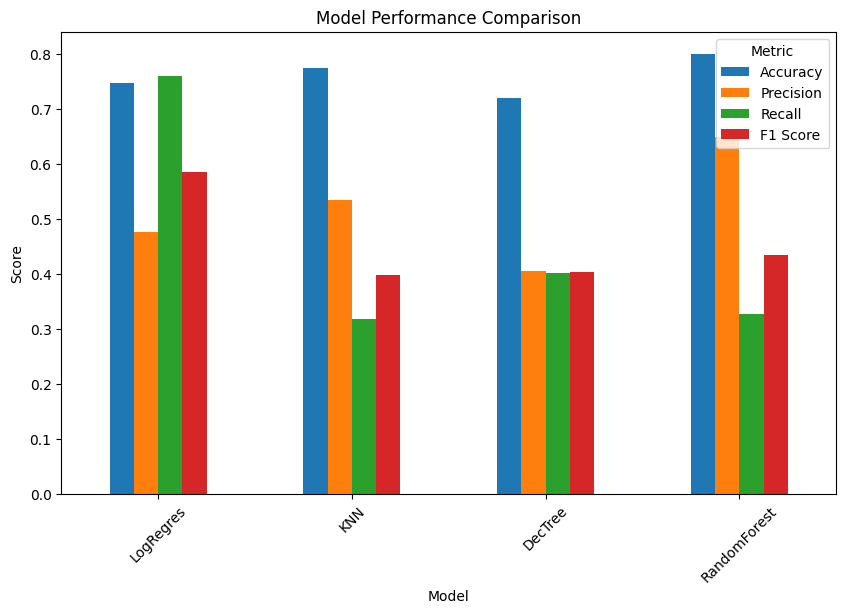

In [11]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.show()

This bar chart compares the performance of each model across four evaluation metrics: accuracy, precision, recall, and F1 score. While Random Forest achieves the highest accuracy and precision, Logistic Regression demonstrates the highest recall, meaning it is better at identifying students who are at risk of dropping out. In this context, recall is more important than overall accuracy because failing to identify at-risk students (false negatives) could prevent timely intervention, making Logistic Regression a more suitable model despite its lower overall accuracy.

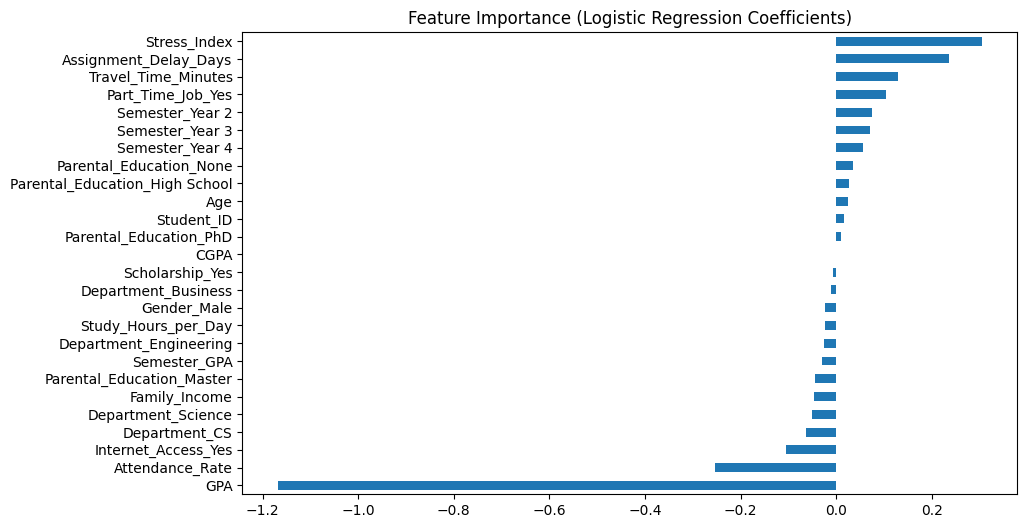

In [12]:
feature_names = X_train.columns
coefficients = winner.coef_[0]

importance = pd.Series(coefficients, index=feature_names)
importance = importance.sort_values()

plt.figure(figsize=(10,6))
importance.plot(kind='barh')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.show()

The feature importance analysis reveals that GPA is the strongest predictor of student dropout, with higher GPA significantly reducing the likelihood of dropping out. Additionally, variables such as study hours and attendance rate show negative relationships with dropout, indicating that increased academic engagement lowers risk. On the other hand, higher stress levels and longer commute times appear to increase the likelihood of dropout. This suggests that both academic performance and external lifestyle factors play a crucial role in student retention.

In [13]:
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogRegres,0.7465,0.476064,0.760085,0.585446
1,KNN,0.7740,0.533808,0.318471,0.398936
2,DecTree,0.7200,0.404711,0.401274,0.402985
3,RandomForest,0.8000,0.649789,0.326964,0.435028


Although Random Forest had the highest overall accuracy at 80%, which had meant it made the most correct predictions all together, we felt that accuracy isn't really the greatest metric for what were trying to accomplish with our project. Given that our projects main goal is to figure out which students are a bit more at risk of dropping out, we felt that recall is a better metric as it tells us how many actual dropout studnts that the model was actually able to get.

After looking at it through this new lense, we saw that the logistic regression had the highest recall at 76% which meant it was the best model to detect students that were actually going to drop out. Although KNN and Random Forest had higher accuracy scores than logisitic regression, their recall scores were markedly lower than that off the logistic regression (31% and 32%). Since the goal of this project is to identify students who may need support, we prioritized recall over accuracy and chose logistic regression as our final model.

The confusion matrix for the final confusion matrix for the logistic regression was as follows:

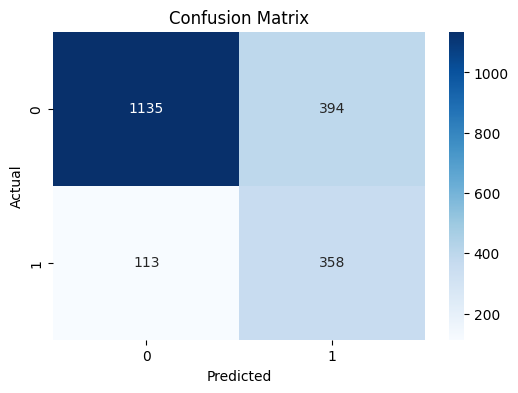

In [14]:
cm = confusion_matrix(y_test, winner_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

This means that the model correct id'd 1135 students who did not drop out and 358 students who did drop out. It wrongly flagged 394 non-dropout students as droupout risks and missed 113 student who actually did drop out. We felt that the 394 incorrect flags were not of issue because its not really harmful to flag someone as a dropout risk whereas it would be really bad to not flag an at risk student. The most important result was that the model caught 358 out of 471 acutal dropout students, giving it a dropout recall of 76%.

# **Insights & Conclusions**

The key takeaways from this project are both practical and analytical. From our statistical analysis, we found that GPA has a strong and statistically significant relationship with student dropout, while factors like scholarship status did not show a meaningful impact, suggesting that academic performance plays a much larger role in determining whether a student leaves school. When applying classification models, we observed that while some models achieved higher overall accuracy, they were less effective at identifying students who actually dropped out. Logistic Regression, which achieved the highest recall (76%), proved to be the most suitable model for this problem because it was better at detecting at-risk students, aligning with the real-world goal of early intervention. Although this resulted in a higher number of false positives, this tradeoff is acceptable in an educational setting, where it is more important to provide support to potentially at-risk students than to miss those who truly need help. Overall, the analysis highlights that academic performance, particularly GPA, is one of the strongest indicators of dropout risk, and this insight could help institutions monitor student progress and intervene earlier. From a methodological standpoint, this project demonstrates a complete data analysis pipeline, beginning with data cleaning and hypothesis testing and extending into model evaluation and interpretation, ensuring that conclusions are supported by both statistical evidence and predictive analysis. However, there are limitations to consider, including the fact that the dataset may not capture important external factors such as personal challenges or mental health, and that model performance could be further improved through additional feature engineering or tuning. In conclusion, this project shows how data-driven approaches can be used to better understand and predict student dropout, producing insights that are not only statistically sound but also practically useful for improving student support and retention.